<a href="https://colab.research.google.com/github/ashish06-official/Attrtion_Prediction/blob/main/Employee_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Required modules**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import pickle
from sklearn.model_selection import train_test_split, cross_val_score
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**2.Loading the Dataset**

In [4]:
df = pd.read_csv("/content/Employee Churn Dataset.csv")
df.shape # gives the structure of the dataframe
df.head(5) # Gives the first 5 rows



,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
pd.set_option("display.max_columns",None) # to display all 35 coloumns
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

**2.1 Let's Remove unwanted coloumns**

In [7]:
df.drop(columns=["DailyRate","HourlyRate","MonthlyRate","PerformanceRating",
                 "TrainingTimesLastYear","RelationshipSatisfaction",
                 "StockOptionLevel","Gender"], inplace=True, errors='ignore')

In [8]:
df.shape

(1470, 27)

In [9]:
for col in df.columns:
  print(col,df[col].unique())
  print("-"*50)

Age [41 49 37 33 27 32 59 30 38 36 35 29 31 34 28 22 53 24 21 42 44 46 39 43
 50 26 48 55 45 56 23 51 40 54 58 20 25 19 57 52 47 18 60]
--------------------------------------------------
Attrition ['Yes' 'No']
--------------------------------------------------
BusinessTravel ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
--------------------------------------------------
Department ['Sales' 'Research & Development' 'Human Resources']
--------------------------------------------------
DistanceFromHome [ 1  8  2  3 24 23 27 16 15 26 19 21  5 11  9  7  6 10  4 25 12 18 29 22
 14 20 28 17 13]
--------------------------------------------------
Education [2 1 4 3 5]
--------------------------------------------------
EducationField ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
--------------------------------------------------
EmployeeCount [1]
--------------------------------------------------
EmployeeNumber [   1    2    4 ... 2064 2065 2068]
----

In [10]:
df.drop(columns=["Over18","StandardHours","EmployeeCount","EmployeeNumber"],inplace = True)


In [11]:
df.shape


(1470, 23)

In [12]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EnvironmentSatisfaction',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'TotalWorkingYears', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [13]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1470 non-null   int64 
 1   Attrition                1470 non-null   object
 2   BusinessTravel           1470 non-null   object
 3   Department               1470 non-null   object
 4   DistanceFromHome         1470 non-null   int64 
 5   Education                1470 non-null   int64 
 6   EducationField           1470 non-null   object
 7   EnvironmentSatisfaction  1470 non-null   int64 
 8   JobInvolvement           1470 non-null   int64 
 9   JobLevel                 1470 non-null   int64 
 10  JobRole                  1470 non-null   object
 11  JobSatisfaction          1470 non-null   int64 
 12  MaritalStatus            1470 non-null   object
 13  MonthlyIncome            1470 non-null   int64 
 14  NumCompaniesWorked       1470 non-null  

In [14]:
print(df.isnull().sum())

Age                        0
Attrition                  0
BusinessTravel             0
Department                 0
DistanceFromHome           0
Education                  0
EducationField             0
EnvironmentSatisfaction    0
JobInvolvement             0
JobLevel                   0
JobRole                    0
JobSatisfaction            0
MaritalStatus              0
MonthlyIncome              0
NumCompaniesWorked         0
OverTime                   0
PercentSalaryHike          0
TotalWorkingYears          0
WorkLifeBalance            0
YearsAtCompany             0
YearsInCurrentRole         0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
dtype: int64


In [15]:
print(df.Attrition.value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [16]:
df.shape

(1470, 23)

In [17]:
df.describe()

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,TotalWorkingYears,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,9.192517,2.912925,2.721769,2.729932,2.063946,2.728571,6502.931293,2.693197,15.209524,11.279592,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,8.106864,1.024165,1.093082,0.711561,1.106940,1.102846,4707.956783,2.498009,3.659938,7.780782,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1009.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2911.000000,1.000000,12.000000,6.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,7.000000,3.000000,3.000000,3.000000,2.000000,3.000000,4919.000000,2.000000,14.000000,10.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,14.000000,4.000000,4.000000,3.000000,3.000000,4.000000,8379.000000,4.000000,18.000000,15.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,29.000000,5.000000,4.000000,4.000000,5.000000,4.000000,19999.000000,9.000000,25.000000,40.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [18]:
def histogram(df,colname):

  plt.figure(figsize=(6,4))
  sns.histplot(df[colname]) # kde = true is used for getting curves
  plt.title(f"Graph of {colname}")
  colmedian =df[colname].median()
  plt.axvline(colmedian,color = "red",linestyle = "-",label = "Median")
  colmode = df[colname].mode
  colmean = df[colname].mean()
  plt.axvline(colmean,color = "blue",linestyle = "--",label = "Mean")
  plt.legend()
  plt.show()

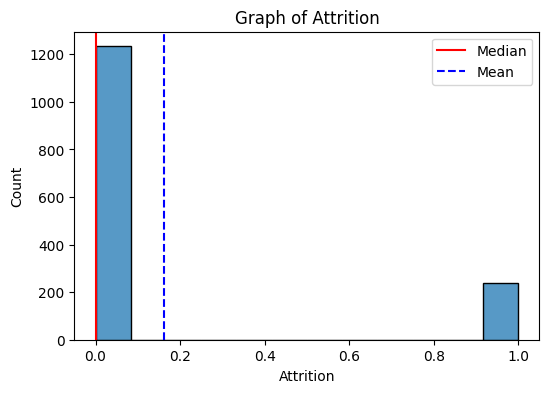

In [19]:
temp_df = df.copy()
temp_df['Attrition'] = temp_df['Attrition'].map({'No': 0, 'Yes': 1})
histogram(temp_df,"Attrition")

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1470 non-null   int64 
 1   Attrition                1470 non-null   object
 2   BusinessTravel           1470 non-null   object
 3   Department               1470 non-null   object
 4   DistanceFromHome         1470 non-null   int64 
 5   Education                1470 non-null   int64 
 6   EducationField           1470 non-null   object
 7   EnvironmentSatisfaction  1470 non-null   int64 
 8   JobInvolvement           1470 non-null   int64 
 9   JobLevel                 1470 non-null   int64 
 10  JobRole                  1470 non-null   object
 11  JobSatisfaction          1470 non-null   int64 
 12  MaritalStatus            1470 non-null   object
 13  MonthlyIncome            1470 non-null   int64 
 14  NumCompaniesWorked       1470 non-null  

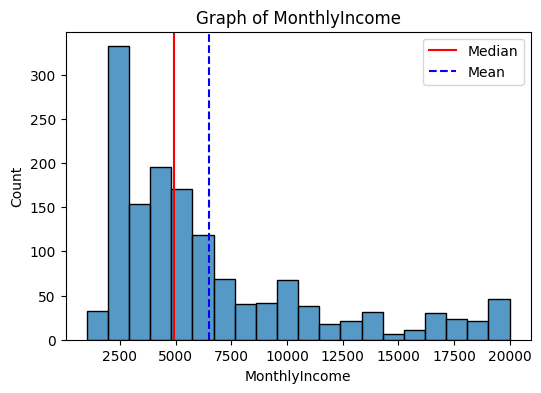

In [21]:
histogram(df,"MonthlyIncome")

**Let's create a BoxPlot for further Analysis**

In [22]:
def Boxplot(df,colname):
  plt.figure(figsize=(6,4))
  sns.boxplot(y=df[colname])
  plt.title(f"Boxplot of {colname}")
  plt.ylabel(colname)
  plt.show()

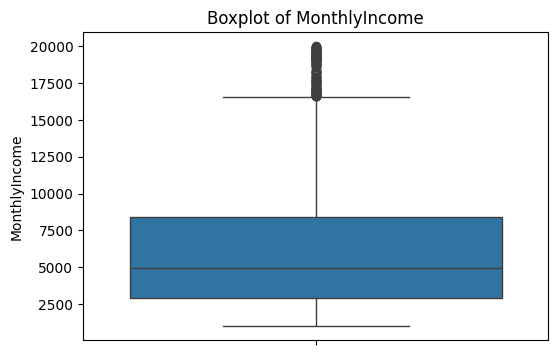

In [23]:
Boxplot(df,"MonthlyIncome")

Attrition Boxplot

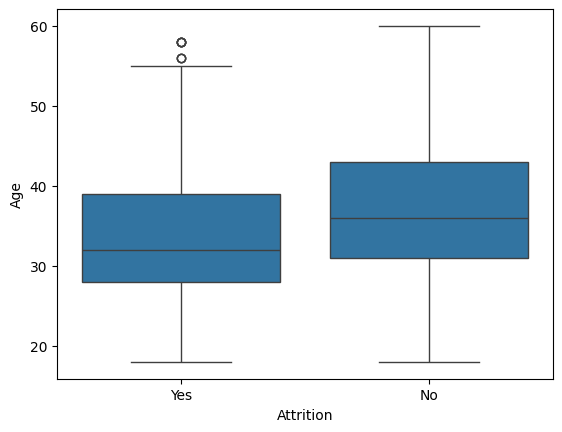

In [24]:
sns.boxplot(x="Attrition", y="Age", data=df)
plt.show()

**Label encoding**

In [25]:
df['Attrition'] = df['Attrition'].map({
    "No": 0,
    "Yes": 1
})

In [26]:
objcoloumn = df.select_dtypes(include="object").columns.to_list()
print(objcoloumn)

['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus', 'OverTime']


In [27]:
df["Attrition"].value_counts()

,count
Attrition,
0,1233
1,237


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1470 non-null   int64 
 1   Attrition                1470 non-null   int64 
 2   BusinessTravel           1470 non-null   object
 3   Department               1470 non-null   object
 4   DistanceFromHome         1470 non-null   int64 
 5   Education                1470 non-null   int64 
 6   EducationField           1470 non-null   object
 7   EnvironmentSatisfaction  1470 non-null   int64 
 8   JobInvolvement           1470 non-null   int64 
 9   JobLevel                 1470 non-null   int64 
 10  JobRole                  1470 non-null   object
 11  JobSatisfaction          1470 non-null   int64 
 12  MaritalStatus            1470 non-null   object
 13  MonthlyIncome            1470 non-null   int64 
 14  NumCompaniesWorked       1470 non-null  

Encoding object coloumn to int

In [29]:
encoder = {}

for col in objcoloumn:
  labelencoder = LabelEncoder()
  df[col] = labelencoder.fit_transform(df[col])
  encoder[col] = labelencoder

with open("encoder.pkl","wb") as f:
  pickle.dump(encoder,f)

In [30]:
df.head(3)

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,OverTime,PercentSalaryHike,TotalWorkingYears,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,2,1,2,1,2,3,2,7,4,2,5993,8,1,11,8,1,6,4,0,5
1,49,0,1,1,8,1,1,3,2,2,6,2,1,5130,1,0,23,10,3,10,7,1,7
2,37,1,2,1,2,2,4,4,2,1,2,3,2,2090,6,1,15,7,3,0,0,0,0


**Train Test Spliting**

In [31]:
x = df.drop(columns=["Attrition"])
y = df["Attrition"]

xtrain , xtest , ytrain , ytest = train_test_split(x,y,test_size=0.2,random_state=42)
print(xtrain.value_counts())
print(ytrain.value_counts())

Age  BusinessTravel  Department  DistanceFromHome  Education  EducationField  EnvironmentSatisfaction  JobInvolvement  JobLevel  JobRole  JobSatisfaction  MaritalStatus  MonthlyIncome  NumCompaniesWorked  OverTime  PercentSalaryHike  TotalWorkingYears  WorkLifeBalance  YearsAtCompany  YearsInCurrentRole  YearsSinceLastPromotion  YearsWithCurrManager
60   2               2           16                4          2               1                        3               2         7        1                2              5405           8                   0         14                 10                 3                2               2                   2                        2                       1
18   0               1           1                 3          1               4                        3               1         2        4                2              1611           1                   0         15                 0                  4                0               0    

**Minortiy Oversampling using SMOTE**

In [32]:
smote = SMOTE(random_state=42)
xtrain_smote, ytrain_smote = smote.fit_resample(xtrain, ytrain)
print(ytrain.shape)
print(ytrain_smote.shape)


print(ytrain.value_counts())
print(ytrain_smote.value_counts())

(1176,)
(1956,)
Attrition
0    978
1    198
Name: count, dtype: int64
Attrition
0    978
1    978
Name: count, dtype: int64


**Cross validations**

In [33]:

models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}


cvscores = {}
for name , model in models.items():
  score = cross_val_score(model,xtrain_smote,ytrain_smote,cv=8,scoring = "accuracy")
  cvscores[name]= score
  print(f"Cross validation accuracy of {name} : {np.mean(score):.3f} ")

Cross validation accuracy of Decision Tree : 0.820 
Cross validation accuracy of Random Forest : 0.904 


In [34]:
cvscores

{'Decision Tree': array([0.71020408, 0.72653061, 0.87346939, 0.86122449, 0.88114754,
        0.85245902, 0.81967213, 0.83606557]),
 'Random Forest': array([0.80408163, 0.84489796, 0.94285714, 0.93061224, 0.93442623,
        0.93852459, 0.9057377 , 0.93442623])}

Random forest has higher accuracy

In [35]:
rf = RandomForestClassifier(random_state=42)
rf.fit(xtrain_smote,ytrain_smote)

ytest_pred = rf.predict(xtest)
print(f"Accuracy score : {accuracy_score(ytest,ytest_pred)}")
print(f"Confusion Matrix : {confusion_matrix(ytest,ytest_pred)}")
print(f"Classification Report : {classification_report(ytest,ytest_pred)}")

Accuracy score : 0.8605442176870748
Confusion Matrix : [[241  14]
 [ 27  12]]
Classification Report :               precision    recall  f1-score   support

           0       0.90      0.95      0.92       255
           1       0.46      0.31      0.37        39

    accuracy                           0.86       294
   macro avg       0.68      0.63      0.65       294
weighted avg       0.84      0.86      0.85       294



Most important feature for predicting


                    Feature  Importance
12            MonthlyIncome    0.089665
10          JobSatisfaction    0.071337
6   EnvironmentSatisfaction    0.057509
0                       Age    0.057316
16        TotalWorkingYears    0.056129
19       YearsInCurrentRole    0.054754
3          DistanceFromHome    0.053765
21     YearsWithCurrManager    0.052595
7            JobInvolvement    0.051753
18           YearsAtCompany    0.051483
17          WorkLifeBalance    0.048203
15        PercentSalaryHike    0.042084
1            BusinessTravel    0.041354
9                   JobRole    0.040804
8                  JobLevel    0.038456
--------------------------------------------------------------------------------


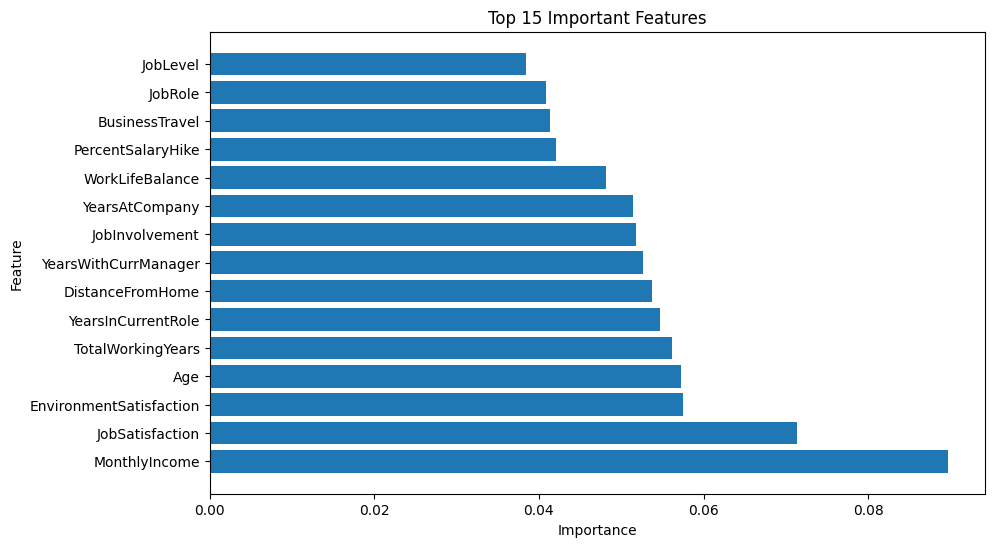

In [36]:

importance_df = pd.DataFrame({
    'Feature': xtrain_smote.columns,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head(15))
print("--"*40)

plt.figure(figsize=(10,6))
plt.barh(
    importance_df['Feature'][:15],
    importance_df['Importance'][:15]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Important Features")
plt.show()

**Save and Load the data**

In [37]:
model_data = {"model": rf , "feature_name ": x.columns.to_list()}

with open ("customerChurnModel.pkl",'wb') as f:
  pickle.dump(model_data,f)

In [38]:
with open ("customerChurnModel.pkl",'rb') as ff:
  pickle.load(ff)
loaded_model = model_data["model"]
loaded_feature_names = model_data["feature_name "]
print(loaded_model)
print(loaded_feature_names)

RandomForestClassifier(random_state=42)
['Age', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'TotalWorkingYears', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [39]:
input_data = {
    "Age": 41,
    "BusinessTravel": "Travel_Rarely",
    "Department": "Sales",
    "DistanceFromHome": 1,
    "Education": 2,
    "EducationField": "Life Sciences",
    "EnvironmentSatisfaction": 2,
    "JobInvolvement": 3,
    "JobLevel": 2,
    "JobRole": "Sales Executive",
    "JobSatisfaction": 4,
    "MaritalStatus": "Single",
    "MonthlyIncome": 5993,
    "NumCompaniesWorked": 8,
    "OverTime": "Yes",
    "PercentSalaryHike": 11,
    "TotalWorkingYears": 8,
    "WorkLifeBalance": 1,
    "YearsAtCompany": 6,
    "YearsInCurrentRole": 4,
    "YearsSinceLastPromotion": 0,
    "YearsWithCurrManager": 5
}

In [40]:
input_df = pd.DataFrame([input_data])

with open("encoder.pkl","rb") as f:
  encoder = pickle.load(f)

print(input_df)

for col,encoder in encoder.items():
  input_df[col] = encoder.transform(input_df[col])

input_df

   Age BusinessTravel Department  DistanceFromHome  Education EducationField  \
0   41  Travel_Rarely      Sales                 1          2  Life Sciences   

   EnvironmentSatisfaction  JobInvolvement  JobLevel          JobRole  \
0                        2               3         2  Sales Executive   

   JobSatisfaction MaritalStatus  MonthlyIncome  NumCompaniesWorked OverTime  \
0                4        Single           5993                   8      Yes   

   PercentSalaryHike  TotalWorkingYears  WorkLifeBalance  YearsAtCompany  \
0                 11                  8                1               6   

   YearsInCurrentRole  YearsSinceLastPromotion  YearsWithCurrManager  
0                   4                        0                     5  


,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,OverTime,PercentSalaryHike,TotalWorkingYears,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,2,2,1,2,1,2,3,2,7,4,2,5993,8,1,11,8,1,6,4,0,5


In [41]:
prediction = loaded_model.predict(input_df)
prediction_probablity = loaded_model.predict_proba(input_df)

print(prediction)
print(f"Prediction : {'Attrition' if prediction == 1 else 'NO Attrition'}")
print(prediction_probablity)

[1]
Prediction : Attrition
[[0.03 0.97]]
